# Brazilian E-Commerce SQL Analytics Deep Dive
### Turning 100K+ Orders into Business Intelligence

**Author:** Tobi Bolu
**Tools:** DuckDB, Python, Plotly
**Dataset:** [Olist Brazilian E-Commerce (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

## Overview

This analysis explores the Olist Brazilian e-commerce dataset using **advanced SQL** to uncover actionable business insights across five analytical dimensions: revenue performance, customer retention, seller quality, delivery operations, and customer lifetime value.

Every insight is generated through SQL queries executed via DuckDB, demonstrating proficiency in CTEs, window functions, cohort analysis, and business-oriented data storytelling.

---

## Setup & Data Loading

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

# Download dataset from Kaggle (cached after first run)
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
DATA_DIR = path
print("Dataset downloaded to:", DATA_DIR)


/Users/tobibolu/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Dataset downloaded to: /Users/tobibolu/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2


In [2]:
# Initialize DuckDB (in-memory) and load all tables
con = duckdb.connect()

tables = {
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

for table_name, filename in tables.items():
    filepath = os.path.join(DATA_DIR, filename)
    con.execute(
        f"CREATE TABLE {table_name} AS SELECT * FROM read_csv_auto('{filepath}')"
    )
    row_count = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    print(f"  {table_name}: {row_count:,} rows")

print("\nAll tables loaded successfully.")

  orders: 99,441 rows
  order_items: 112,650 rows
  customers: 99,441 rows
  products: 32,951 rows
  sellers: 3,095 rows
  payments: 103,886 rows
  reviews: 99,224 rows
  geolocation: 1,000,163 rows
  category_translation: 71 rows

All tables loaded successfully.


In [3]:
# Quick schema overview
for table_name in tables.keys():
    cols = con.execute(f"DESCRIBE {table_name}").fetchdf()
    print(f"\n--- {table_name} ---")
    for _, row in cols.iterrows():
        print(f"  {row['column_name']:40s} {row['column_type']}")


--- orders ---
  order_id                                 VARCHAR
  customer_id                              VARCHAR
  order_status                             VARCHAR
  order_purchase_timestamp                 TIMESTAMP
  order_approved_at                        TIMESTAMP
  order_delivered_carrier_date             TIMESTAMP
  order_delivered_customer_date            TIMESTAMP
  order_estimated_delivery_date            TIMESTAMP

--- order_items ---
  order_id                                 VARCHAR
  order_item_id                            BIGINT
  product_id                               VARCHAR
  seller_id                                VARCHAR
  shipping_limit_date                      TIMESTAMP
  price                                    DOUBLE
  freight_value                            DOUBLE

--- customers ---
  customer_id                              VARCHAR
  customer_unique_id                       VARCHAR
  customer_zip_code_prefix                 VARCHAR
  customer_city  

---
## Section 1: Revenue Breakdown

**Business question:** Where is revenue coming from, how is it trending, and which segments are driving growth?

I'm using window functions (`LAG`, `SUM() OVER`, `RANK()`) to calculate month-over-month growth rates, running totals, and category-level revenue rankings.

In [4]:
# Monthly revenue trend with MoM growth
monthly_revenue = con.execute("""
    WITH monthly AS (
        SELECT
            DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month,
            COUNT(DISTINCT o.order_id)                      AS total_orders,
            ROUND(SUM(oi.price + oi.freight_value), 2)      AS total_revenue
        FROM orders o
        JOIN order_items oi
          ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1
    )

    SELECT
        order_month,
        total_orders,
        total_revenue,
        LAG(total_revenue) OVER (ORDER BY order_month) AS prev_month_revenue,
        ROUND(
            (total_revenue - LAG(total_revenue) OVER (ORDER BY order_month))
            / NULLIF(LAG(total_revenue) OVER (ORDER BY order_month), 0) * 100,
            1
        ) AS mom_growth_pct,
        SUM(total_revenue) OVER (ORDER BY order_month) AS running_total
    FROM monthly
    ORDER BY order_month
""").fetchdf()

monthly_revenue

,order_month,total_orders,total_revenue,prev_month_revenue,mom_growth_pct,running_total
0,2016-09-01,1,143.46,NaN,NaN,143.46
1,2016-10-01,265,46490.66,143.46,32306.7,46634.12
2,2016-12-01,1,19.62,46490.66,-100.0,46653.74
3,2017-01-01,750,127482.37,19.62,649657.2,174136.11
4,2017-02-01,1653,271239.32,127482.37,112.8,445375.43
5,2017-03-01,2546,414330.95,271239.32,52.8,859706.38
6,2017-04-01,2303,390812.40,414330.95,-5.7,1250518.78
7,2017-05-01,3546,566851.40,390812.40,45.0,1817370.18
8,2017-06-01,3135,490050.37,566851.40,-13.5,2307420.55
9,2017-07-01,3872,566299.08,490050.37,15.6,2873719.63


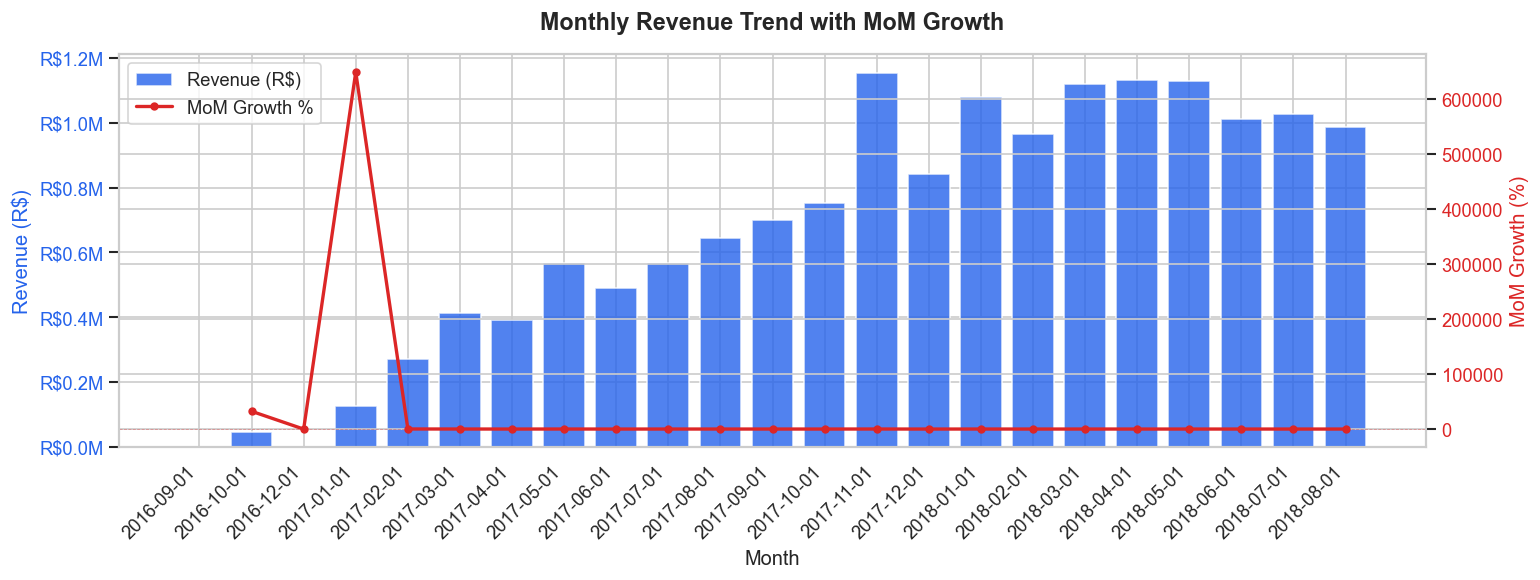

In [5]:
# Visualize: Monthly revenue trend with MoM growth
fig, ax1 = plt.subplots(figsize=(13, 5))

color_bar = '#2563eb'
color_line = '#dc2626'

ax1.bar(monthly_revenue['order_month'].astype(str), monthly_revenue['total_revenue'],
        color=color_bar, alpha=0.8, label='Revenue (R$)')
ax1.set_xlabel('Month')
ax1.set_ylabel(r'Revenue (R\$)', color=color_bar)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly_revenue['order_month'].astype(str), monthly_revenue['mom_growth_pct'],
         color=color_line, linewidth=2, marker='o', markersize=4, label='MoM Growth %')
ax2.set_ylabel('MoM Growth (%)', color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.axhline(0, color=color_line, linewidth=0.5, linestyle='--', alpha=0.4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Monthly Revenue Trend with MoM Growth', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [6]:
# 1b. Revenue by product category (Top 15) with ranking
category_revenue = con.execute("""
    WITH category_sales AS (
        SELECT
            COALESCE(ct.product_category_name_english, p.product_category_name) AS category,
            ROUND(SUM(oi.price), 2)            AS total_revenue,
            COUNT(DISTINCT oi.order_id)         AS order_count,
            ROUND(AVG(oi.price), 2)             AS avg_order_value
        FROM order_items oi
        JOIN products p
          ON oi.product_id = p.product_id
        LEFT JOIN category_translation ct
          ON p.product_category_name = ct.product_category_name
        JOIN orders o
          ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1
    )

    SELECT
        category,
        total_revenue,
        order_count,
        avg_order_value,
        RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank,
        ROUND(total_revenue / SUM(total_revenue) OVER () * 100, 1) AS pct_of_total
    FROM category_sales
    ORDER BY total_revenue DESC
    LIMIT 15
""").fetchdf()

category_revenue

,category,total_revenue,order_count,avg_order_value,revenue_rank,pct_of_total
0,health_beauty,1233131.72,8647,130.28,1,9.3
1,watches_gifts,1166176.98,5495,199.04,2,8.8
2,bed_bath_table,1023434.76,9272,93.44,3,7.7
3,sports_leisure,954852.55,7530,113.25,4,7.2
4,computers_accessories,888724.61,6530,116.26,5,6.7
5,furniture_decor,711927.69,6307,87.25,6,5.4
6,housewares,615628.69,5743,90.60,7,4.7
7,cool_stuff,610204.10,3559,164.12,8,4.6
8,auto,578966.65,3810,139.85,9,4.4
9,toys,471286.48,3804,116.94,10,3.6


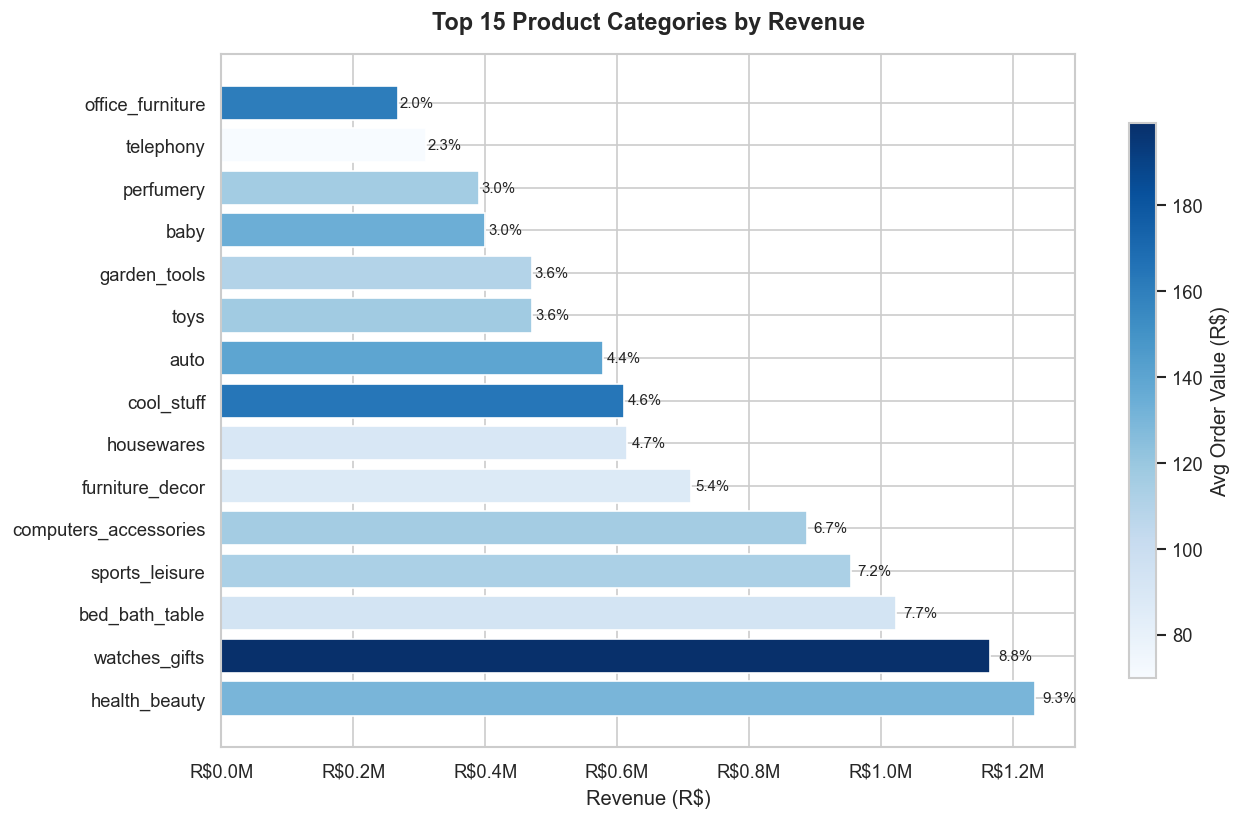

In [7]:
# Visualize: Top 15 categories by revenue
fig, ax = plt.subplots(figsize=(11, 7))

norm = plt.Normalize(category_revenue['avg_order_value'].min(), category_revenue['avg_order_value'].max())
colors = plt.cm.Blues(norm(category_revenue['avg_order_value']))

bars = ax.barh(category_revenue['category'], category_revenue['total_revenue'],
               color=colors)
for bar, pct in zip(bars, category_revenue['pct_of_total']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)

sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Avg Order Value (R$)', shrink=0.8)

ax.set_title('Top 15 Product Categories by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(r'Revenue (R\$)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()


In [8]:
# 1c. Revenue by customer state (Top 10) with per-capita comparison
state_revenue = con.execute("""
    SELECT
        c.customer_state                     AS state,
        COUNT(DISTINCT o.order_id)           AS total_orders,
        COUNT(DISTINCT c.customer_unique_id) AS unique_customers,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue,
        ROUND(
            SUM(oi.price + oi.freight_value)
            / COUNT(DISTINCT c.customer_unique_id), 2
        ) AS revenue_per_customer
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN customers c    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY total_revenue DESC
    LIMIT 10
""").fetchdf()

state_revenue

,state,total_orders,unique_customers,total_revenue,revenue_per_customer
0,SP,40501,39156,5769703.15,147.35
1,RJ,12350,11917,2055401.57,172.48
2,MG,11354,11001,1818891.67,165.34
3,RS,5345,5168,861472.79,166.69
4,PR,4923,4769,781708.80,163.91
5,SC,3546,3449,595127.78,172.55
6,BA,3256,3158,591137.81,187.19
7,DF,2080,2019,346123.35,171.43
8,GO,1957,1895,334212.35,176.37
9,ES,1995,1928,317657.93,164.76


### What this means for the business

Total platform revenue reached R\$15.4M across ~96K delivered orders over two years. The growth trajectory is clear: revenue climbed from essentially zero in late 2016 to consistently above R\$1M/month by early 2018, with November 2017 hitting R\$1.15M (likely driven by Black Friday, a 53.6% MoM spike).

Revenue is heavily concentrated geographically. Sao Paulo alone accounts for R\$5.77M (37% of total) with 39K unique customers. But the per-customer revenue tells a different story: BA (R\$187), GO (R\$176), SC (R\$173), and RJ (R\$172) all outperform SP's R\$147 per customer. That gap suggests SP customers may be buying lower-value items, or that smaller states have higher average order values worth investigating for expansion.

On the category side, Health & Beauty leads at 9.3% of revenue (R\$1.23M), but no single category dominates. The top 5 categories collectively account for less than 40% of total revenue, which is healthy diversification. Watches & Gifts stands out with the highest avg order value at R\$199, nearly double most other categories, making it a strong candidate for targeted upselling.

---
## Section 2: Customer Cohort & Retention Analysis

**Business question:** Are we retaining customers? Which acquisition cohorts perform best over time?

Cohort retention is the single most commonly requested analytical framework in senior analyst interviews. I'm grouping customers by their first purchase month, then tracking repurchase behavior across subsequent months.

In [9]:
# Cohort retention matrix
cohort_data = con.execute("""
    WITH first_purchase AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1
    ),

    all_purchases AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', o.order_purchase_timestamp) AS purchase_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    ),

    cohort_activity AS (
        SELECT
            fp.cohort_month,
            DATEDIFF('month', fp.cohort_month, ap.purchase_month) AS months_since_first,
            COUNT(DISTINCT ap.customer_unique_id) AS active_customers
        FROM first_purchase fp
        JOIN all_purchases ap
          ON fp.customer_unique_id = ap.customer_unique_id
        GROUP BY 1, 2
    ),

    cohort_sizes AS (
        SELECT
            cohort_month,
            COUNT(*) AS cohort_size
        FROM first_purchase
        GROUP BY 1
    )

    SELECT
        ca.cohort_month,
        cs.cohort_size,
        ca.months_since_first,
        ca.active_customers,
        ROUND(ca.active_customers * 100.0 / cs.cohort_size, 2) AS retention_pct
    FROM cohort_activity ca
    JOIN cohort_sizes cs
      ON ca.cohort_month = cs.cohort_month
    WHERE ca.months_since_first BETWEEN 0 AND 12
    ORDER BY ca.cohort_month, ca.months_since_first
""").fetchdf()

# Pivot into a retention matrix
retention_matrix = cohort_data.pivot_table(
    index='cohort_month',
    columns='months_since_first',
    values='retention_pct',
    aggfunc='first'
)

# Keep months 0 through 6 and drop rows without data
retention_matrix = retention_matrix[retention_matrix.columns[:7]]
retention_matrix = retention_matrix.dropna(subset=[0])

retention_matrix.head(12)

months_since_first,0,1,2,3,4,5,6
cohort_month,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.38
2016-12-01,100.0,100.00,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42
2017-02-01,100.0,0.18,0.31,0.12,0.43,0.12,0.25
2017-03-01,100.0,0.44,0.36,0.40,0.36,0.16,0.16
2017-04-01,100.0,0.62,0.22,0.18,0.27,0.27,0.35
2017-05-01,100.0,0.46,0.46,0.29,0.29,0.32,0.41
2017-06-01,100.0,0.49,0.40,0.43,0.30,0.40,0.36


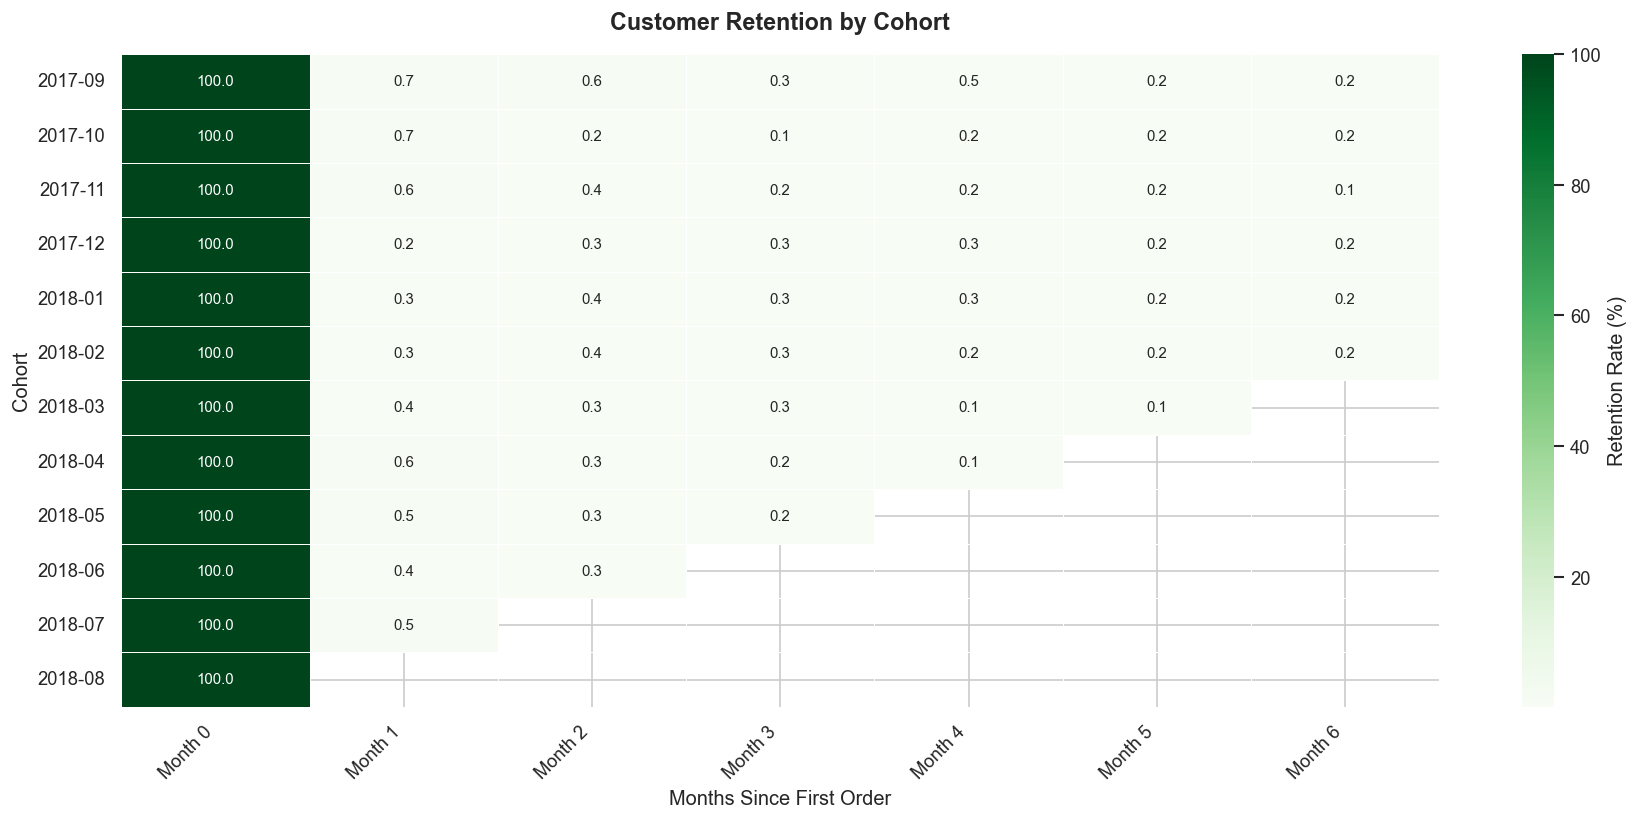

In [10]:
# Visualize: Cohort retention heatmap
matrix_display = retention_matrix.tail(12).copy()
matrix_display.index = [str(d)[:7] for d in matrix_display.index]

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(matrix_display, annot=True, fmt='.1f', cmap='Greens',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Retention Rate (%)'},
            annot_kws={'size': 9})
ax.set_title('Customer Retention by Cohort', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Order')
ax.set_ylabel('Cohort')
ax.set_xticklabels([f'Month {int(c)}' for c in retention_matrix.columns],
                   rotation=45, ha='right')
plt.tight_layout()
plt.show()


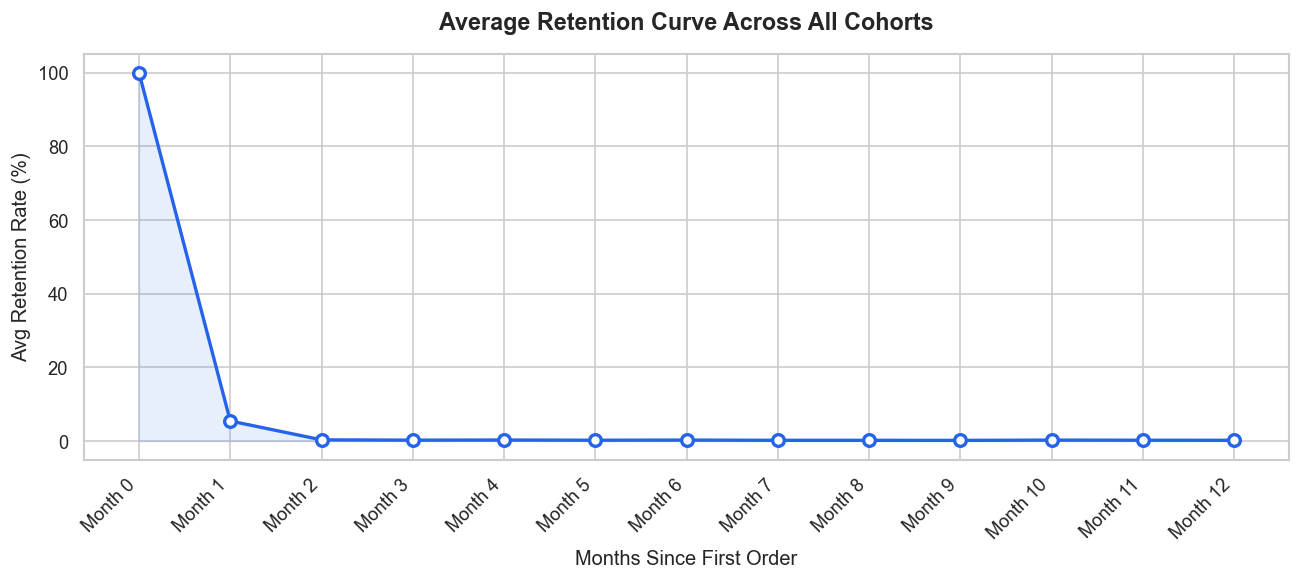

In [11]:
# Average retention curve across all cohorts
avg_retention = con.execute("""
    WITH first_purchase AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1
    ),

    all_purchases AS (
        SELECT
            c.customer_unique_id,
            DATE_TRUNC('month', o.order_purchase_timestamp) AS purchase_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    ),

    cohort_data AS (
        SELECT
            fp.cohort_month,
            ap.purchase_month,
            DATEDIFF('month', fp.cohort_month, ap.purchase_month) AS period_number,
            COUNT(DISTINCT ap.customer_unique_id) AS active_customers
        FROM first_purchase fp
        JOIN all_purchases ap ON fp.customer_unique_id = ap.customer_unique_id
        GROUP BY 1, 2, 3
    ),

    cohort_sizes AS (
        SELECT cohort_month, active_customers AS cohort_size
        FROM cohort_data
        WHERE period_number = 0
    )

    SELECT
        cd.period_number,
        AVG(100.0 * cd.active_customers / cs.cohort_size) AS avg_retention
    FROM cohort_data cd
    JOIN cohort_sizes cs ON cd.cohort_month = cs.cohort_month
    WHERE cd.period_number <= 12
    GROUP BY 1
    ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(avg_retention['period_number'], avg_retention['avg_retention'],
        marker='o', linewidth=2, markersize=7, color='#2563eb',
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(avg_retention['period_number'], avg_retention['avg_retention'],
                alpha=0.1, color='#2563eb')
ax.set_xticks(avg_retention['period_number'])
ax.set_xticklabels([f'Month {int(p)}' for p in avg_retention['period_number']],
                   rotation=45, ha='right')
ax.set_title('Average Retention Curve Across All Cohorts', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Order')
ax.set_ylabel('Avg Retention Rate (%)')
plt.tight_layout()
plt.show()


### What this means for the business

The most important finding in the entire analysis is right here. Average retention drops from 100% to just 5.45% by month 1, and then to 0.34% by month 2. That means roughly 97% of customers never come back after their first purchase.

Some context matters here: Olist operates as a marketplace aggregator, so many customers don't even realize they purchased through Olist. They think they bought directly from the seller. That structural factor partially explains the near-zero retention, but it also represents a massive opportunity. If the platform could surface its own brand identity at the point of purchase and follow up with a branded re-engagement touchpoint, even converting 2-3% of one-time buyers into repeat customers would meaningfully move revenue.

The cohort matrix shows retention is relatively flat across acquisition months (hovering around 0.3-0.7% at month 1 for most cohorts), which means this isn't a seasonal or quality problem. It's a systemic platform visibility issue. The retention curve flattens after month 2, suggesting that the small percentage of customers who do return tend to remain somewhat active over time.

---
## Section 3: Seller Performance Ranking

**Business question:** Which sellers are top performers, and how should we tier them?

Uses `NTILE`, `PERCENT_RANK`, and multi-metric scoring to create a seller performance scorecard.

In [12]:
# 3a. Seller scorecard with percentile ranking
seller_scorecard = con.execute("""
    WITH seller_metrics AS (
        SELECT
            s.seller_id,
            s.seller_city,
            s.seller_state,
            COUNT(DISTINCT oi.order_id)  AS total_orders,
            ROUND(SUM(oi.price), 2)      AS total_revenue,
            ROUND(AVG(oi.price), 2)      AS avg_item_price,
            ROUND(AVG(r.review_score), 2) AS avg_review_score,
            COUNT(DISTINCT r.review_id)  AS review_count
        FROM sellers s
        JOIN order_items oi ON s.seller_id = oi.seller_id
        JOIN orders o       ON oi.order_id = o.order_id
        LEFT JOIN reviews r ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1, 2, 3
        HAVING COUNT(DISTINCT oi.order_id) >= 5
    )

    SELECT
        seller_id,
        seller_city,
        seller_state,
        total_orders,
        total_revenue,
        avg_item_price,
        avg_review_score,
        NTILE(4) OVER (ORDER BY total_revenue DESC) AS revenue_quartile,
        ROUND(PERCENT_RANK() OVER (ORDER BY total_revenue) * 100, 1) AS revenue_percentile,
        ROUND(PERCENT_RANK() OVER (ORDER BY avg_review_score) * 100, 1) AS review_percentile,
        CASE
            WHEN NTILE(4) OVER (ORDER BY total_revenue DESC) = 1
             AND avg_review_score >= 4.0
            THEN 'Gold'
            WHEN NTILE(4) OVER (ORDER BY total_revenue DESC) <= 2
            THEN 'Silver'
            WHEN avg_review_score < 3.0
            THEN 'At Risk'
            ELSE 'Standard'
        END AS seller_tier
    FROM seller_metrics
    ORDER BY total_revenue DESC
""").fetchdf()

print(f"Total qualified sellers: {len(seller_scorecard)}")
print(f"\nTier distribution:")
print(seller_scorecard['seller_tier'].value_counts().to_string())
print(f"\nTop 10 sellers:")
seller_scorecard.head(10)

Total qualified sellers: 1766

Tier distribution:
seller_tier
Standard    850
Silver      580
Gold        304
At Risk      32

Top 10 sellers:


,seller_id,seller_city,seller_state,total_orders,total_revenue,avg_item_price,avg_review_score,revenue_quartile,revenue_percentile,review_percentile,seller_tier
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1124,226987.93,197.72,4.14,1,100.0,43.1,Gold
1,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,348,217940.44,544.85,4.13,1,99.9,41.2,Gold
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1772,199408.32,101.17,3.83,1,99.9,19.5,Silver
3,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,578,190917.14,329.74,4.37,1,99.8,66.6,Gold
4,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,973,188063.83,137.67,3.35,1,99.8,5.9,Silver
5,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,319,165981.49,515.47,4.36,1,99.7,65.3,Gold
6,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1311,162303.67,103.31,4.08,1,99.7,37.6,Gold
7,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1145,140238.65,121.00,4.27,1,99.6,55.9,Gold
8,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,910,139720.16,97.43,3.87,1,99.5,21.5,Silver
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1261,131906.71,89.49,4.09,1,99.5,38.2,Gold


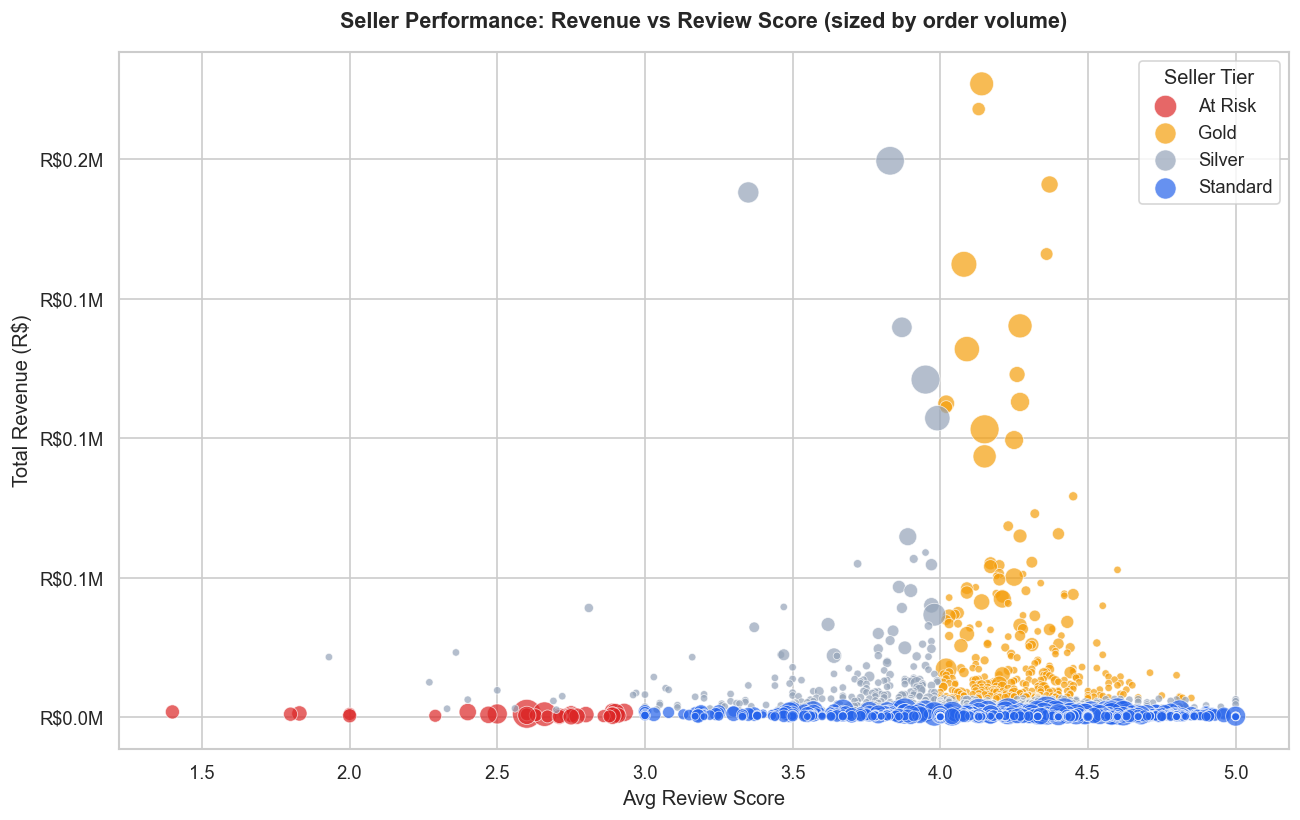

In [13]:
# Visualize: Seller performance scatter
tier_colors = {'Gold': '#f59e0b', 'Silver': '#94a3b8', 'Standard': '#2563eb', 'At Risk': '#dc2626'}
fig, ax = plt.subplots(figsize=(11, 7))

for tier, grp in seller_scorecard.groupby('seller_tier'):
    sizes = (grp['total_orders'] / grp['total_orders'].max() * 300).clip(lower=20)
    ax.scatter(grp['avg_review_score'], grp['total_revenue'],
               s=sizes, c=tier_colors.get(tier, '#888'),
               label=tier, alpha=0.7, edgecolors='white', linewidth=0.5)

ax.set_title('Seller Performance: Revenue vs Review Score (sized by order volume)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Avg Review Score')
ax.set_ylabel(r'Total Revenue (R\$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.legend(title='Seller Tier')
plt.tight_layout()
plt.show()


### What this means for the business

Out of 1,766 qualified sellers (those with at least 5 orders), 304 earned Gold status (top revenue quartile with 4.0+ average review score). These sellers should be the backbone of the marketplace, they're driving both revenue and customer satisfaction simultaneously.

The 32 "At Risk" sellers are the ones worth flagging immediately: they have sub-3.0 review scores, meaning their customers are actively unhappy. On a marketplace where the platform's reputation is tied to seller quality, these sellers are doing brand damage that affects everyone. A minimum review score threshold (say, 3.5) with a grace period and improvement plan would protect the customer experience.

There's also an interesting gap between revenue and reviews in the Silver tier. Some high-revenue sellers aren't making it to Gold because their review scores sit just below 4.0. That's worth investigating, are they selling high-demand products with long delivery times? The delivery analysis in Section 4 might explain some of that.

---
## Section 4: Delivery Funnel Analysis

**Business question:** Where are the bottlenecks in our fulfillment process, and which regions suffer the worst delays?

Tracks orders through each stage (purchased, approved, shipped, delivered) with time-between-stages and regional breakdowns.

In [14]:
# 4a. Delivery funnel: average time at each stage
delivery_funnel = con.execute("""
    SELECT
        COUNT(*) AS total_orders,

        COUNT(CASE WHEN order_approved_at IS NOT NULL THEN 1 END)
            AS approved,
        COUNT(CASE WHEN order_delivered_carrier_date IS NOT NULL THEN 1 END)
            AS shipped,
        COUNT(CASE WHEN order_delivered_customer_date IS NOT NULL THEN 1 END)
            AS delivered,

        ROUND(AVG(
            DATEDIFF('hour', order_purchase_timestamp, order_approved_at)
        ), 1) AS avg_hours_to_approval,

        ROUND(AVG(
            DATEDIFF('hour', order_approved_at, order_delivered_carrier_date)
        ) / 24.0, 1) AS avg_days_to_ship,

        ROUND(AVG(
            DATEDIFF('hour', order_delivered_carrier_date, order_delivered_customer_date)
        ) / 24.0, 1) AS avg_days_in_transit,

        ROUND(AVG(
            DATEDIFF('hour', order_purchase_timestamp, order_delivered_customer_date)
        ) / 24.0, 1) AS avg_total_days,

        ROUND(AVG(
            DATEDIFF('hour', order_purchase_timestamp, order_estimated_delivery_date)
        ) / 24.0, 1) AS avg_estimated_days,

        ROUND(
            COUNT(CASE
                WHEN order_delivered_customer_date > order_estimated_delivery_date
                THEN 1
            END) * 100.0
            / NULLIF(COUNT(CASE
                WHEN order_delivered_customer_date IS NOT NULL
                THEN 1
            END), 0),
            1
        ) AS pct_delivered_late

    FROM orders
    WHERE order_status = 'delivered'
""").fetchdf()

delivery_funnel.T

,0
total_orders,96478.0
approved,96464.0
shipped,96476.0
delivered,96470.0
avg_hours_to_approval,10.3
avg_days_to_ship,2.8
avg_days_in_transit,9.3
avg_total_days,12.6
avg_estimated_days,23.8
pct_delivered_late,8.1


In [15]:
# 4b. Delivery performance by state (worst delays)
state_delivery = con.execute("""
    SELECT
        c.customer_state AS state,
        COUNT(*) AS delivered_orders,
        ROUND(AVG(
            DATEDIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date)
        ), 1) AS avg_delivery_days,
        ROUND(AVG(
            DATEDIFF('day', o.order_delivered_carrier_date, o.order_delivered_customer_date)
        ), 1) AS avg_transit_days,
        ROUND(
            COUNT(CASE
                WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
                THEN 1
            END) * 100.0 / COUNT(*),
            1
        ) AS pct_late
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 1
    HAVING COUNT(*) >= 50
    ORDER BY avg_delivery_days DESC
""").fetchdf()

state_delivery

,state,delivered_orders,avg_delivery_days,avg_transit_days,pct_late
0,AP,67,27.2,23.7,4.5
1,AM,145,26.4,23.4,4.1
2,AL,397,24.5,21.1,23.9
3,PA,946,23.7,20.3,12.4
4,MA,717,21.5,17.9,19.7
5,SE,335,21.5,17.9,15.2
6,CE,1279,21.2,17.9,15.3
7,AC,80,21.0,17.5,3.8
8,PB,517,20.4,16.9,11.0
9,PI,476,19.4,16.3,16.0


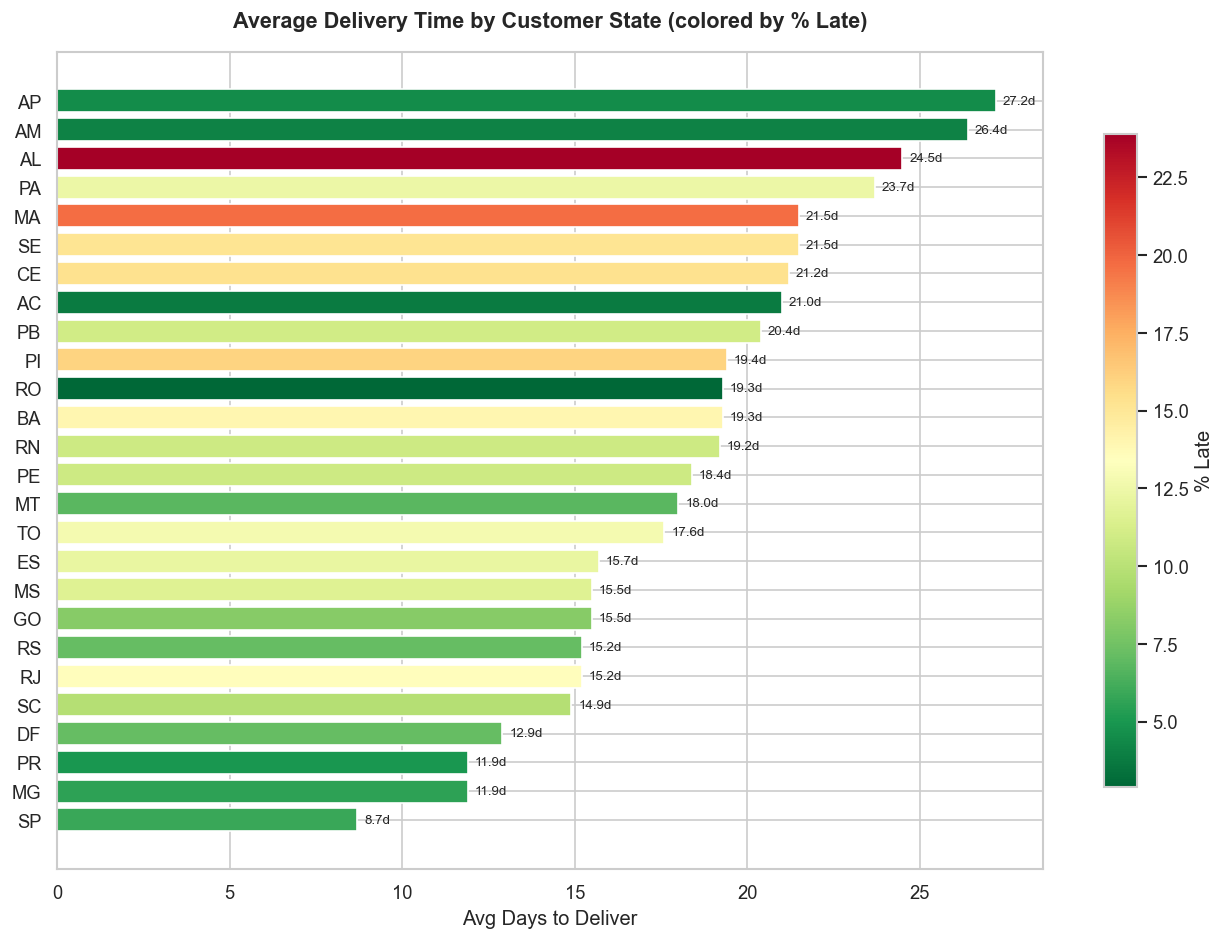

In [16]:
# Visualize: Delivery days by state
data = state_delivery.sort_values('avg_delivery_days', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
norm = plt.Normalize(data['pct_late'].min(), data['pct_late'].max())
colors = plt.cm.RdYlGn_r(norm(data['pct_late']))

bars = ax.barh(data['state'], data['avg_delivery_days'], color=colors)
for bar, val in zip(bars, data['avg_delivery_days']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}d', va='center', fontsize=8)

sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='% Late', shrink=0.8)

ax.set_title('Average Delivery Time by Customer State (colored by % Late)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Avg Days to Deliver')
plt.tight_layout()
plt.show()


In [17]:
# 4c. Late delivery impact on reviews
late_impact = con.execute("""
    SELECT
        CASE
            WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date
            THEN 'On Time'
            WHEN DATEDIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) <= 7
            THEN 'Late (1-7 days)'
            ELSE 'Late (7+ days)'
        END AS delivery_status,
        COUNT(*) AS order_count,
        ROUND(AVG(r.review_score), 2) AS avg_review_score,
        ROUND(
            COUNT(CASE WHEN r.review_score <= 2 THEN 1 END) * 100.0 / COUNT(*),
            1
        ) AS pct_negative_reviews
    FROM orders o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 1
    ORDER BY avg_review_score DESC
""").fetchdf()

late_impact

,delivery_status,order_count,avg_review_score,pct_negative_reviews
0,On Time,88653,4.29,9.2
1,Late (1-7 days),4903,3.06,39.7
2,Late (7+ days),2797,1.70,79.2


### What this means for the business

The delivery pipeline is actually solid on average: 10.3 hours to approval, 2.8 days to ship, 9.3 days in transit, 12.6 days total. Only 8.1% of orders arrive late. But the averages hide a significant geographic disparity.

Northern states are a different experience entirely. Amapa (AP) averages 27.2 days to deliver, Amazonas (AM) 26.4 days, and Alagoas (AL) 24.5 days, nearly three times longer than Sao Paulo's 8.7 days. Transit time is the bottleneck, not approval or shipping, which points to carrier/logistics infrastructure rather than seller delays.

The late delivery impact on reviews is stark and actionable. On-time orders average 4.29 stars with just 9.2% negative reviews. Late by 1-7 days drops to 3.06 stars with 39.7% negative reviews. And orders arriving 7+ days late crash to 1.70 stars with 79.2% negative reviews. That's a nearly linear relationship between delay severity and customer dissatisfaction. Every day of improvement in transit time for the worst-performing states would have a measurable positive impact on review scores and, by extension, seller tier classifications.

---
## Section 5: Repeat Purchase & LTV Signals

**Business question:** How many customers come back, and what are the high-value segments worth?

Identifies repeat buyers, calculates repurchase intervals, and estimates a simple 12-month customer lifetime value by segment.

In [18]:
# 5a. Repeat purchase rates
repeat_analysis = con.execute("""
    WITH customer_orders AS (
        SELECT
            c.customer_unique_id,
            COUNT(DISTINCT o.order_id) AS order_count,
            ROUND(SUM(oi.price + oi.freight_value), 2) AS total_spend,
            MIN(o.order_purchase_timestamp) AS first_order,
            MAX(o.order_purchase_timestamp) AS last_order,
            DATEDIFF('day',
                MIN(o.order_purchase_timestamp),
                MAX(o.order_purchase_timestamp)
            ) AS days_between_first_last
        FROM orders o
        JOIN customers c    ON o.customer_id = c.customer_id
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1
    )

    SELECT
        CASE
            WHEN order_count = 1 THEN '1 order (one-time)'
            WHEN order_count = 2 THEN '2 orders'
            WHEN order_count BETWEEN 3 AND 5 THEN '3-5 orders'
            ELSE '6+ orders'
        END AS purchase_frequency,
        COUNT(*) AS customer_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_of_customers,
        ROUND(AVG(total_spend), 2) AS avg_total_spend,
        ROUND(AVG(days_between_first_last), 0) AS avg_days_active
    FROM customer_orders
    GROUP BY 1
    ORDER BY MIN(order_count)
""").fetchdf()

repeat_analysis

,purchase_frequency,customer_count,pct_of_customers,avg_total_spend,avg_days_active
0,1 order (one-time),90557,97.0,160.73,0.0
1,2 orders,2573,2.8,291.03,82.0
2,3-5 orders,218,0.2,490.95,153.0
3,6+ orders,10,0.0,834.81,249.0


In [19]:
# 5b. Simple 12-month LTV estimate by customer state
ltv_by_state = con.execute("""
    WITH customer_metrics AS (
        SELECT
            c.customer_unique_id,
            c.customer_state,
            COUNT(DISTINCT o.order_id) AS order_count,
            ROUND(SUM(oi.price + oi.freight_value), 2) AS total_spend,
            DATEDIFF('month',
                MIN(o.order_purchase_timestamp),
                MAX(o.order_purchase_timestamp)
            ) + 1 AS months_active
        FROM orders o
        JOIN customers c    ON o.customer_id = c.customer_id
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1, 2
    )

    SELECT
        customer_state AS state,
        COUNT(*) AS total_customers,
        ROUND(AVG(order_count), 2) AS avg_orders,
        ROUND(AVG(total_spend), 2) AS avg_spend,
        ROUND(
            AVG(total_spend / GREATEST(months_active, 1)) * 12,
            2
        ) AS estimated_12mo_ltv,
        ROUND(
            COUNT(CASE WHEN order_count > 1 THEN 1 END) * 100.0 / COUNT(*),
            1
        ) AS repeat_purchase_rate
    FROM customer_metrics
    GROUP BY 1
    HAVING COUNT(*) >= 50
    ORDER BY estimated_12mo_ltv DESC
""").fetchdf()

ltv_by_state

,state,total_customers,avg_orders,avg_spend,estimated_12mo_ltv,repeat_purchase_rate
0,PB,504,1.03,273.49,3233.23,2.0
1,AC,76,1.05,257.57,2959.47,5.3
2,RO,231,1.05,246.61,2883.98,3.9
3,AP,66,1.02,244.57,2879.80,1.5
4,AL,387,1.03,243.34,2868.07,2.6
5,PA,922,1.03,229.96,2728.87,2.4
6,PI,464,1.03,226.68,2652.95,2.2
7,TO,267,1.03,224.75,2626.25,2.6
8,RN,464,1.02,217.06,2557.11,2.2
9,CE,1258,1.02,211.79,2513.42,1.6


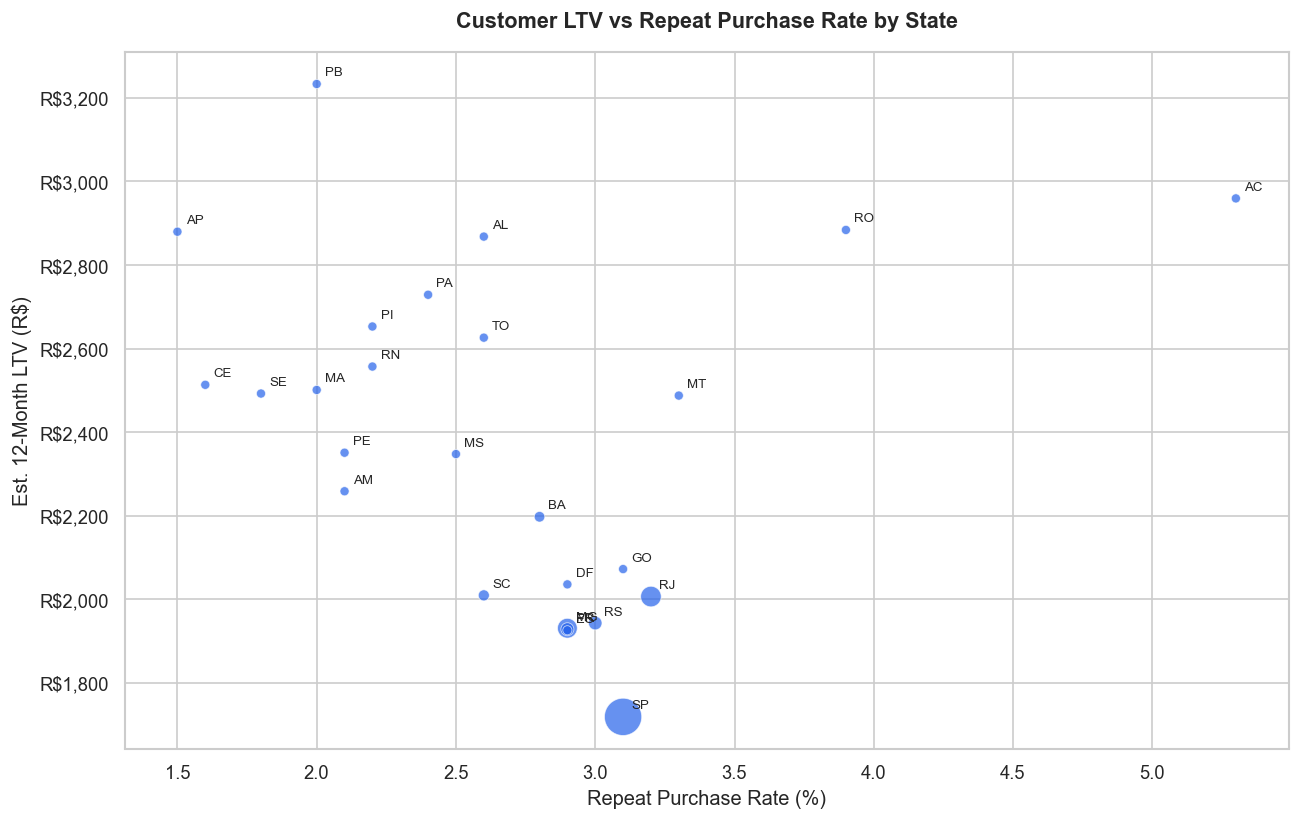

In [20]:
# Visualize: LTV vs Repeat Purchase Rate by state
fig, ax = plt.subplots(figsize=(11, 7))

sizes = (ltv_by_state['total_customers'] / ltv_by_state['total_customers'].max() * 500).clip(lower=30)
scatter = ax.scatter(ltv_by_state['repeat_purchase_rate'], ltv_by_state['estimated_12mo_ltv'],
                     s=sizes, color='#2563eb', alpha=0.7, edgecolors='white', linewidth=0.5)

for _, row in ltv_by_state.iterrows():
    ax.annotate(row['state'],
                (row['repeat_purchase_rate'], row['estimated_12mo_ltv']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_title('Customer LTV vs Repeat Purchase Rate by State',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Repeat Purchase Rate (%)')
ax.set_ylabel(r'Est. 12-Month LTV (R\$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.tight_layout()
plt.show()


In [21]:
# 5c. Repurchase gap analysis (for repeat customers only)
repurchase_gap = con.execute("""
    WITH customer_order_sequence AS (
        SELECT
            c.customer_unique_id,
            o.order_purchase_timestamp,
            LAG(o.order_purchase_timestamp) OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp
            ) AS prev_order_date,
            DATEDIFF('day',
                LAG(o.order_purchase_timestamp) OVER (
                    PARTITION BY c.customer_unique_id
                    ORDER BY o.order_purchase_timestamp
                ),
                o.order_purchase_timestamp
            ) AS days_since_last_order
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    )

    SELECT
        CASE
            WHEN days_since_last_order <= 30 THEN '0-30 days'
            WHEN days_since_last_order <= 60 THEN '31-60 days'
            WHEN days_since_last_order <= 90 THEN '61-90 days'
            WHEN days_since_last_order <= 180 THEN '91-180 days'
            ELSE '180+ days'
        END AS repurchase_window,
        COUNT(*) AS repurchase_count,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
            1
        ) AS pct_of_repurchases
    FROM customer_order_sequence
    WHERE days_since_last_order IS NOT NULL
    GROUP BY 1
    ORDER BY MIN(days_since_last_order)
""").fetchdf()

repurchase_gap

,repurchase_window,repurchase_count,pct_of_repurchases
0,0-30 days,1568,50.3
1,31-60 days,360,11.5
2,61-90 days,221,7.1
3,91-180 days,462,14.8
4,180+ days,509,16.3


### What this means for the business

97% of customers are one-time buyers. The 3% who return spend significantly more: two-time buyers average R\$291 total (versus R\$161 for one-time), and the small group of 3-5 order customers averages R\$491. The 10 customers with 6+ orders average R\$835 and stay active for about 249 days. These power users are extremely valuable, but there are almost none of them.

The repurchase gap analysis reveals the critical intervention window: 50.3% of all repeat purchases happen within 30 days of the previous order. Another 11.5% happen in the 31-60 day window. That means the first 60 days after a purchase is when a customer is most likely to come back, and after 90 days, the probability drops significantly. An automated re-engagement campaign triggered at the 21-day and 45-day marks would hit the optimal window.

On LTV by state, there's a counterintuitive pattern: smaller, more remote states (PB at R\$3,233, AC at R\$2,959, RO at R\$2,884) show the highest estimated 12-month LTV, while SP, the highest-volume state, has the lowest at R\$1,719. This is likely because customers in remote states pay higher freight costs (which inflate their total spend). But it also means these customers are already spending more per transaction, so the marginal cost of a retention campaign could have an outsized return in these markets.

---
## Executive Summary

### Key Findings

**1. R\$15.4M in revenue across 96K orders, with strong growth trajectory.** The platform scaled from near-zero to consistently over R\$1M/ month in about 18 months. November 2017 hit R\$1.15M, likely driven by Black Friday (53.6% MoM growth). Revenue is geographically concentrated in SP (37%), but per-customer spend is actually higher in smaller states like BA (R\$187) and GO (R\$176) compared to SP (R\$147).

**2. 97% of customers never return, the single biggest opportunity for growth.** The cohort retention matrix shows that average retention drops to 5.45% by month 1 and below 1% by month 2. This is partly structural (marketplace aggregator model), but even a modest improvement in repeat purchase rate would compound into significant revenue. The 3% of customers who do return spend 1.8x to 5.2x more than one-time buyers.

**3. 304 Gold-tier sellers drive the marketplace, but 32 sellers are actively harming the brand.** Of 1,766 qualified sellers, the tiering framework identifies a clear quality spectrum. "At Risk" sellers (sub-3.0 review scores) need intervention or removal. Several high-revenue Silver sellers sit just below the Gold threshold due to borderline review scores, worth investigating for delivery-related issues.

**4. Late deliveries destroy customer satisfaction in a near-linear pattern.** On-time orders average 4.29 stars (9.2% negative reviews). Late by 1-7 days: 3.06 stars (39.7% negative). Late by 7+ days: 1.70 stars (79.2% negative). Northern states face 2-3x longer transit times than SP, with Amapa averaging 27.2 days versus SP's 8.7.

**5. The re-engagement window is 30 days.** 50.3% of repeat purchases happen within 30 days of the previous order, and 61.8% within 60 days. After 90 days, the probability of return drops significantly. This defines exactly when automated retention campaigns should fire.

### Recommended Actions

1. Launch a 21-day and 45-day post-purchase re-engagement campaign targeting first-time buyers, focusing on the 30-day window where 50% of repeat purchases occur
2. Implement the seller tier system with a minimum 3.5 review score threshold, with improvement plans for At Risk sellers and premium placement for Gold sellers
3. Investigate logistics partnerships or regional fulfillment solutions for the northern states where transit times are 2-3x the platform average
4. Increase marketing investment in high-LTV states (PB, AC, RO, AL) that show R\$2,800+ estimated 12-month LTV, nearly double SP's R\$1,719
5. Surface the Olist brand identity at the point of purchase and in post-purchase communications to build platform-level awareness and improve structural retention

---
*Analysis by Tobi Bolu | [LinkedIn](https://www.linkedin.com/in/tobibolu/) | [GitHub](https://github.com/tobibolu)*